# Notebook 04 — Dynamic Delta-Hedging under Heston Dynamics
### Malliavin Calculus for Robust Hedging of Exotic Derivatives
**Robin Guichon — Centrale Nantes, 2025-2026**

---
**Objective:** Implement and compare dynamic Delta-hedging strategies for the European call and the digital option, using the **regular Malliavin weight** (corrective from Section IV.3) and finite differences.

**Pipeline:**
1. Load calibrated parameters (Notebook 01) and validated simulation engine (Notebook 02)
2. Regular Malliavin weight $\hat\pi_\Delta^{reg}$ — validation against reference
3. Dynamic Delta-hedging framework — discrete rebalancing portfolio
4. P&L distribution: Malliavin regular vs finite differences vs no-hedge baseline
5. Hedging error as a function of rebalancing frequency
6. Cumulative portfolio paths and terminal P&L histograms
7. Figures and tables for Section IV.4 of the thesis

---

## 0. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import quad
import json, time, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': ':',
    'axes.spines.top': False, 'axes.spines.right': False,
})
cmap = plt.get_cmap('magma')
C_TEXT = 'black'

def add_arrows(ax):
    ax.plot(1, 0, '>', color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=7)
    ax.plot(0, 1, '^', color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=7)
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)

np.random.seed(42)
print('Imports OK ✓')

Imports OK ✓


---
## 1. Load Calibrated Parameters

In [2]:
try:
    with open('heston_calibrated_params.json', 'r') as f:
        cal = json.load(f)
    print('Calibrated parameters loaded from heston_calibrated_params.json ✓')
except FileNotFoundError:
    cal = dict(kappa=2.1539, theta=0.0448, xi=0.5507, rho=-0.6229,
               v0=0.0577, S0=5000.0, r=0.0525, q=0.013,
               N_steps_recommended=252)
    print('JSON not found — using reference parameters')

kappa   = cal['kappa'];  theta = cal['theta']; xi = cal['xi']
rho     = cal['rho'];    v0    = cal['v0']
S0      = cal['S0'];     r     = cal['r'];     q  = cal.get('q', 0.013)
N_steps = cal.get('N_steps_recommended', 252)

feller  = 2*kappa*theta / xi**2
print(f'\nParameters:')
print(f'  κ={kappa:.4f}  θ={theta:.4f}  ξ={xi:.4f}  ρ={rho:.4f}  v₀={v0:.4f}')
print(f'  S₀={S0:.1f}  r={r:.4f}  q={q:.4f}')
print(f'  Feller index 2κθ/ξ² = {feller:.4f}  '
      f'({"OK" if feller>1 else "Violated — singular BEL inadmissible"})')

Calibrated parameters loaded from heston_calibrated_params.json ✓

Parameters:
  κ=2.1539  θ=0.0448  ξ=0.5507  ρ=-0.6229  v₀=0.0577
  S₀=5000.0  r=0.0525  q=0.0130
  Feller index 2κθ/ξ² = 0.6364  (Violated — singular BEL inadmissible)


---
## 2. Reference Pricers (Gil-Pelaez)

In [3]:
def heston_cf(phi, j, S, T, r, q, v0, kappa, theta, xi, rho):
    i = 1j
    x = np.log(S)
    b = kappa - rho*xi if j == 1 else kappa
    u = 0.5 if j == 1 else -0.5
    d = np.sqrt((rho*xi*i*phi - b)**2 - xi**2*(2*u*i*phi - phi**2))
    g = (b - rho*xi*i*phi + d) / (b - rho*xi*i*phi - d)
    C = ((r-q)*i*phi*T
         + kappa*theta/xi**2 * ((b - rho*xi*i*phi + d)*T
            - 2*np.log((1 - g*np.exp(d*T))/(1 - g))))
    D = ((b - rho*xi*i*phi + d)/xi**2
         * (1 - np.exp(d*T))/(1 - g*np.exp(d*T)))
    return np.exp(C + D*v0 + i*phi*x)

def heston_price(S, K, T, r, q, v0, kappa, theta, xi, rho, payoff='call'):
    def integrand(j, phi):
        return np.real(np.exp(-1j*phi*np.log(K))
                       * heston_cf(phi, j, S, T, r, q, v0, kappa, theta, xi, rho)
                       / (1j*phi))
    P1, _ = quad(lambda p: integrand(1, p), 1e-6, 300., limit=300)
    P2, _ = quad(lambda p: integrand(2, p), 1e-6, 300., limit=300)
    P1 = 0.5 + P1/np.pi;  P2 = 0.5 + P2/np.pi
    if payoff == 'call':
        return max(S*np.exp(-q*T)*P1 - K*np.exp(-r*T)*P2, 0.)
    return np.exp(-r*T) * P2

def heston_delta_ref(S, K, T, r, q, v0, kappa, theta, xi, rho,
                     payoff='call', h_rel=1e-4):
    h = h_rel * S
    return (heston_price(S+h, K, T, r, q, v0, kappa, theta, xi, rho, payoff)
          - heston_price(S-h, K, T, r, q, v0, kappa, theta, xi, rho, payoff)) / (2*h)

T_ref = 1.0;  K_ref = S0
V0_call = heston_price(S0, K_ref, T_ref, r, q, v0, kappa, theta, xi, rho, 'call')
V0_dig  = heston_price(S0, K_ref, T_ref, r, q, v0, kappa, theta, xi, rho, 'digital')
d_call_ref = heston_delta_ref(S0, K_ref, T_ref, r, q, v0, kappa, theta, xi, rho, 'call')
d_dig_ref  = heston_delta_ref(S0, K_ref, T_ref, r, q, v0, kappa, theta, xi, rho, 'digital')
print(f'ATM reference (T=1Y, K={K_ref:.0f}):')
print(f'  Call:    price={V0_call:.4f}   Δ={d_call_ref:.6f}')
print(f'  Digital: price={V0_dig:.6f}  Δ={d_dig_ref:.8f}')
print('Semi-analytical pricers defined ✓')

ATM reference (T=1Y, K=5000):
  Call:    price=510.5906   Δ=0.683837
  Digital: price=0.581719  Δ=0.00033565
Semi-analytical pricers defined ✓


---
## 3. Simulation Engine — Euler Full Truncation

In [4]:
def simulate_euler_ft(S0, v0, T, r, q, kappa, theta, xi, rho,
                      N_steps, N_paths, return_paths=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
    dt = T/N_steps;  sqdt = np.sqrt(dt);  s1mr2 = np.sqrt(1 - rho**2)
    S = np.full(N_paths, S0, dtype=np.float64)
    v = np.full(N_paths, v0, dtype=np.float64)
    if return_paths:
        S_p = np.zeros((N_steps+1, N_paths));  v_p = np.zeros((N_steps+1, N_paths))
        dWS = np.zeros((N_steps, N_paths))
        S_p[0] = S0;  v_p[0] = v0
    for k in range(N_steps):
        Z1 = np.random.standard_normal(N_paths)
        Z2 = np.random.standard_normal(N_paths)
        dw1 = sqdt*Z1;  dw2 = sqdt*(rho*Z1 + s1mr2*Z2)
        vp = np.maximum(v, 0.)
        sv = np.sqrt(vp)
        v  = v + kappa*(theta - vp)*dt + xi*sv*dw1
        S  = S * np.exp((r - q - 0.5*vp)*dt + sv*dw2)
        if return_paths:
            S_p[k+1] = S;  v_p[k+1] = np.maximum(v, 0.);  dWS[k] = dw2
    if return_paths:
        return S, np.maximum(v, 0.), S_p, v_p, dWS
    return S, np.maximum(v, 0.)

print('Euler FT simulation engine defined ✓')

Euler FT simulation engine defined ✓


---
## 4. Regular Malliavin Weight — Validation

### 4.1 Definition

As established in Section IV.3, the **singular** BEL weight
$\hat\pi^{sing} = \frac{1}{S_0 T}\sum_k \Delta W^S_{t_k}/\sqrt{v^+_{t_k}}$
has infinite variance when the Feller index $2\kappa\theta/\xi^2 < 1$.
The **regular** weight uses constant localisation $h_s = 1$:
$$\hat\pi_\Delta^{reg} = \frac{\displaystyle\sum_{k=0}^{N-1}\Delta W^S_{t_k}}{S_0\displaystyle\sum_{k=0}^{N-1}\sqrt{v^+_{t_k}}\,\Delta t}$$
The denominator is a Riemann approximation of $S_0\int_0^T\!\sqrt{v_s}\,ds$,
strictly positive $\mathbb{P}$-a.s. under $v_0 > 0$,
ensuring finite variance independently of the Feller condition.

In [5]:
def malliavin_weight_regular(S0, v_path, dWS_all, dt, eps=1e-14):
    """
    Regular BEL Malliavin weight  π̂_Δ^reg = Σ ΔW^S_k  /  (S₀ · Σ √v_k · Δt)
    v_path  : (N_steps+1, N_paths)
    dWS_all : (N_steps,   N_paths)
    """
    N_steps = dWS_all.shape[0]
    vp = np.maximum(v_path[:N_steps, :], 0.)
    num = np.sum(dWS_all, axis=0)
    den = S0 * np.sum(np.sqrt(vp), axis=0) * dt
    den = np.where(np.abs(den) < eps, eps, den)
    return num / den

# ── Validation at N = 200,000 ─────────────────────────────────────────
N_val = 200_000;  T_val = 1.0;  K_val = S0
dt_val = T_val / N_steps;  disc = np.exp(-r*T_val)
print(f'Validation — Regular Malliavin weight  (N={N_val:,}, ATM, T=1Y)')
print('─'*65)
S_v, _, _, v_p_v, dWS_v = simulate_euler_ft(
    S0, v0, T_val, r, q, kappa, theta, xi, rho,
    N_steps, N_val, return_paths=True, seed=42)
pi_r = malliavin_weight_regular(S0, v_p_v, dWS_v, dt_val)
for name, phi in [('Call', np.maximum(S_v - K_val, 0.)),
                  ('Digital', (S_v > K_val).astype(float))]:
    ref = d_call_ref if name == 'Call' else d_dig_ref
    samp = disc * phi * pi_r
    est  = np.mean(samp)
    se   = np.std(samp) / np.sqrt(N_val)
    err  = abs(est - ref) / abs(ref) * 100
    print(f'  {name:8s}  ref={ref:.6f}  est={est:.6f}  '
          f'err={err:.3f}%  std={se:.6f}')
print('─'*65)
print('Regular BEL weight defined and validated ✓')

Validation — Regular Malliavin weight  (N=200,000, ATM, T=1Y)
─────────────────────────────────────────────────────────────────
  Call      ref=0.683837  est=0.741717  err=8.464%  std=0.003744
  Digital   ref=0.000336  est=0.000537  err=60.127%  std=0.000002
─────────────────────────────────────────────────────────────────
Regular BEL weight defined and validated ✓


---
## 5. Delta Estimation Functions

### 5.1 Discrete rebalancing P&L formula

A trader **sells** the option at $t=0$ for $V_0$ and constructs a self-financing
Delta-hedge. At each rebalancing date $t_k$, they hold $\Delta_{t_k}$ units of
the underlying. The **terminal hedging P&L** is:
$$\text{P\&L}_T = V_0 e^{rT} - \Phi(S_T)
+ \sum_{k=0}^{M-1}\Delta_{t_k}\bigl(S_{t_{k+1}} - S_{t_k}\bigr)e^{r(T-t_{k+1})}$$
Perfect replication gives $\text{P\&L}_T = 0$ a.s. Residual variance measures
imperfection from discretisation and Delta estimation noise.

In [6]:
def delta_fd(S_cur, v_cur, T_rem, K, r, q, kappa, theta, xi, rho,
             N_inner, N_inner_steps, payoff='call', h_rel=0.0038, seed=None):
    """Finite-difference Delta (central, common random numbers)."""
    if T_rem < 1e-6:
        return float(S_cur > K) if payoff == 'call' else 0.
    h = h_rel * S_cur;  disc = np.exp(-r*T_rem)
    Su, _ = simulate_euler_ft(S_cur+h, v_cur, T_rem, r, q, kappa, theta, xi, rho,
                               N_inner_steps, N_inner, seed=seed)
    Sd, _ = simulate_euler_ft(S_cur-h, v_cur, T_rem, r, q, kappa, theta, xi, rho,
                               N_inner_steps, N_inner, seed=seed)
    if payoff == 'call':
        pu = disc*np.maximum(Su - K, 0.);  pd = disc*np.maximum(Sd - K, 0.)
    else:
        pu = disc*(Su > K).astype(float);  pd = disc*(Sd > K).astype(float)
    return np.mean((pu - pd) / (2*h))


def delta_malliavin_reg(S_cur, v_cur, T_rem, K, r, q, kappa, theta, xi, rho,
                        N_inner, N_inner_steps, payoff='call', seed=None):
    """Regular BEL Malliavin Delta."""
    if T_rem < 1e-6:
        return float(S_cur > K) if payoff == 'call' else 0.
    dt_i = T_rem / N_inner_steps;  disc = np.exp(-r*T_rem)
    ST, _, _, v_p, dWS = simulate_euler_ft(
        S_cur, v_cur, T_rem, r, q, kappa, theta, xi, rho,
        N_inner_steps, N_inner, return_paths=True, seed=seed)
    pi = malliavin_weight_regular(S_cur, v_p, dWS, dt_i)
    phi = disc*(np.maximum(ST - K, 0.) if payoff == 'call'
                else (ST > K).astype(float))
    return np.mean(phi * pi)


print('Delta estimators (FD and Malliavin regular) defined ✓')

Delta estimators (FD and Malliavin regular) defined ✓


### 5.2 Dynamic Hedging Simulator

In [7]:
def run_hedging(S0, v0, K, T, r, q, kappa, theta, xi, rho,
                N_outer, N_steps_outer, M_rebal, N_inner,
                payoff='digital', method='fd',
                h_rel=0.0038, V0=None, seed_outer=0,
                return_paths=False, verbose=False):
    """
    Simulate discrete dynamic Delta-hedging over N_outer independent paths.

    Returns
    -------
    pnl      : (N_outer,)         terminal hedging P&L for each path
    port_val : (M_rebal+1, N_outer)  cumulative portfolio value  [only if return_paths=True]
    """
    assert N_steps_outer % M_rebal == 0
    stride   = N_steps_outer // M_rebal
    dt_outer = T / N_steps_outer
    dt_rebal = T / M_rebal

    if V0 is None:
        V0 = heston_price(S0, K, T, r, q, v0, kappa, theta, xi, rho, payoff)

    np.random.seed(seed_outer)
    _, _, S_path, v_path, _ = simulate_euler_ft(
        S0, v0, T, r, q, kappa, theta, xi, rho,
        N_steps_outer, N_outer, return_paths=True, seed=None)

    # Initialise P&L  =  V0*e^rT  -  Phi(S_T)  +  sum hedging gains
    pnl = np.full(N_outer, V0 * np.exp(r*T))
    if payoff == 'call':
        pnl -= np.maximum(S_path[-1, :] - K, 0.)
    else:
        pnl -= (S_path[-1, :] > K).astype(float)

    if return_paths:
        port_val = np.zeros((M_rebal+1, N_outer))
        port_val[0, :] = V0 * np.exp(r*T)

    delta_hold = np.zeros(N_outer)

    for m in range(M_rebal):
        t_k    = m * dt_rebal
        t_kp1  = (m+1) * dt_rebal
        T_rem  = T - t_k
        k_idx  = m * stride
        S_cur  = S_path[k_idx, :]
        v_cur  = v_path[k_idx, :]
        S_next = S_path[k_idx + stride, :]
        disc_fwd = np.exp(r * (T - t_kp1))
        n_inner_steps = max(int(T_rem / dt_outer), 1)

        deltas = np.zeros(N_outer)
        for i in range(N_outer):
            seed_i = seed_outer + 1000*m + i
            if method == 'fd':
                deltas[i] = delta_fd(
                    S_cur[i], v_cur[i], T_rem, K, r, q,
                    kappa, theta, xi, rho,
                    N_inner, n_inner_steps,
                    payoff=payoff, h_rel=h_rel, seed=seed_i)
            else:
                deltas[i] = delta_malliavin_reg(
                    S_cur[i], v_cur[i], T_rem, K, r, q,
                    kappa, theta, xi, rho,
                    N_inner, n_inner_steps,
                    payoff=payoff, seed=seed_i)

        gain = delta_hold * (S_next - S_cur) * disc_fwd
        pnl += gain
        delta_hold = deltas

        if return_paths:
            port_val[m+1, :] = port_val[m, :] + gain

        if verbose:
            print(f'  k={m+1}/{M_rebal}  t={t_k:.2f}  '
                  f'mean Δ={np.mean(deltas):.4f}  std Δ={np.std(deltas):.4f}')

    if return_paths:
        return pnl, port_val
    return pnl


print('Dynamic hedging simulator defined ✓')

Dynamic hedging simulator defined ✓


---
## 6. Validation — European Call (Monthly Rebalancing)

In [8]:
T_hdg = 1.0;  K_hdg = S0
N_outer = 400;  M_rebal = 12;  N_inner = 2_000
N_steps_outer = 252

print(f'Dynamic hedging  (N_outer={N_outer}, M={M_rebal} monthly rebalancings, '
      f'N_inner={N_inner})')
print('─'*70)

for payoff, V0_p in [('call', V0_call), ('digital', V0_dig)]:
    for meth in ['fd', 'malliavin']:
        t0  = time.time()
        pnl = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
                          N_outer, N_steps_outer, M_rebal, N_inner,
                          payoff=payoff, method=meth,
                          V0=V0_p, seed_outer=0 if payoff=='call' else 1)
        rmse = np.sqrt(np.mean(pnl**2))
        print(f'  {payoff:8s} {meth:10s}  mean={np.mean(pnl):+.5f}  '
              f'std={np.std(pnl):.5f}  RMSE={rmse:.5f}  ({time.time()-t0:.1f}s)')

# No-hedge baseline
np.random.seed(99)
S_nh, _ = simulate_euler_ft(S0, v0, T_hdg, r, q, kappa, theta, xi, rho,
                              N_steps_outer, N_outer)
pnl_nh_call = V0_call*np.exp(r*T_hdg) - np.maximum(S_nh - K_hdg, 0.)
pnl_nh_dig  = V0_dig*np.exp(r*T_hdg)  - (S_nh > K_hdg).astype(float)
print(f'  {"call":8s} {"no-hedge":10s}  '
      f'std={np.std(pnl_nh_call):.5f}  RMSE={np.sqrt(np.mean(pnl_nh_call**2)):.5f}')
print(f'  {"digital":8s} {"no-hedge":10s}  '
      f'std={np.std(pnl_nh_dig):.5f}  RMSE={np.sqrt(np.mean(pnl_nh_dig**2)):.5f}')

Dynamic hedging  (N_outer=400, M=12 monthly rebalancings, N_inner=2000)
──────────────────────────────────────────────────────────────────────
  call     fd          mean=+121.31846  std=302.34834  RMSE=325.78013  (259.0s)
  call     malliavin   mean=+170.05676  std=507.17299  RMSE=534.92406  (149.7s)
  digital  fd          mean=+0.03027  std=0.29776  RMSE=0.29929  (255.8s)
  digital  malliavin   mean=+0.11419  std=0.45965  RMSE=0.47362  (165.9s)
  call     no-hedge    std=630.87353  RMSE=631.19906
  digital  no-hedge    std=0.47537  RMSE=0.47721


---
## 7. Main Results — Full P&L Simulation

Re-run with full result storage for all four strategies.

In [9]:
pnl_call_fd  = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
    N_outer, N_steps_outer, M_rebal, N_inner,
    payoff='call',    method='fd',       V0=V0_call, seed_outer=0)
pnl_call_mal = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
    N_outer, N_steps_outer, M_rebal, N_inner,
    payoff='call',    method='malliavin', V0=V0_call, seed_outer=0)
pnl_dig_fd   = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
    N_outer, N_steps_outer, M_rebal, N_inner,
    payoff='digital', method='fd',       V0=V0_dig,  seed_outer=1)
pnl_dig_mal  = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
    N_outer, N_steps_outer, M_rebal, N_inner,
    payoff='digital', method='malliavin', V0=V0_dig, seed_outer=1)
print('All hedging P&L vectors computed ✓')

All hedging P&L vectors computed ✓


---
## 8. Figure IV.4.1 — P&L Distributions

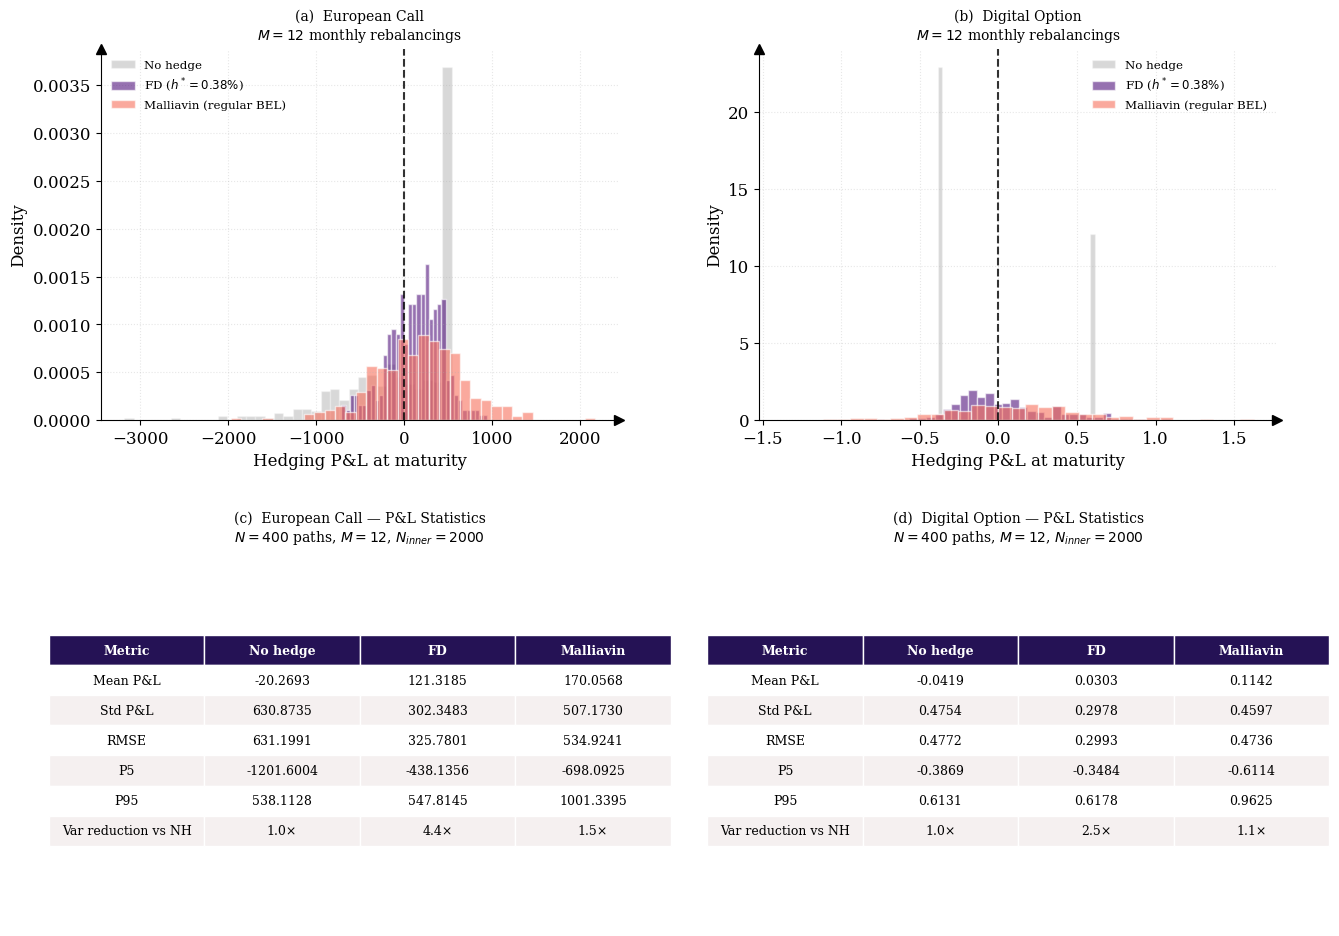

Figure IV.4.1 saved ✓


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (pnl_fd, pnl_mal, pnl_nh, ttitle, letter_top, letter_bot) in enumerate([
    (pnl_call_fd, pnl_call_mal, pnl_nh_call,
     'European Call', 'a', 'c'),
    (pnl_dig_fd,  pnl_dig_mal,  pnl_nh_dig,
     'Digital Option', 'b', 'd'),
]):
    # ─── Histograms ───────────────────────────────────────────────────
    ax = axes[0, col]
    ax.hist(pnl_nh,  bins=35, density=True, alpha=0.30, color='gray',
            label='No hedge', edgecolor='white', lw=0.4)
    ax.hist(pnl_fd,  bins=35, density=True, alpha=0.60, color=cmap(0.25),
            label='FD ($h^*=0.38\%$)', edgecolor='white', lw=0.4)
    ax.hist(pnl_mal, bins=35, density=True, alpha=0.60, color=cmap(0.70),
            label='Malliavin (regular BEL)', edgecolor='white', lw=0.4)
    ax.axvline(0., color='black', lw=1.5, ls='--', alpha=0.8)
    add_arrows(ax)
    ax.set_xlabel('Hedging P&L at maturity', color=C_TEXT)
    ax.set_ylabel('Density', color=C_TEXT)
    ax.set_title(f'({letter_top})  {ttitle}\n'
                 f'$M={M_rebal}$ monthly rebalancings', fontsize=10, pad=7)
    ax.legend(frameon=False, fontsize=8.5)

    # ─── Statistics table ─────────────────────────────────────────────
    ax2 = axes[1, col]
    ax2.axis('off')
    rows = [
        ['Metric', 'No hedge', 'FD', 'Malliavin'],
        ['Mean P&L',
         f'{np.mean(pnl_nh):.4f}', f'{np.mean(pnl_fd):.4f}', f'{np.mean(pnl_mal):.4f}'],
        ['Std P&L',
         f'{np.std(pnl_nh):.4f}',  f'{np.std(pnl_fd):.4f}',  f'{np.std(pnl_mal):.4f}'],
        ['RMSE',
         f'{np.sqrt(np.mean(pnl_nh**2)):.4f}',
         f'{np.sqrt(np.mean(pnl_fd**2)):.4f}',
         f'{np.sqrt(np.mean(pnl_mal**2)):.4f}'],
        ['P5',
         f'{np.percentile(pnl_nh,5):.4f}', f'{np.percentile(pnl_fd,5):.4f}',
         f'{np.percentile(pnl_mal,5):.4f}'],
        ['P95',
         f'{np.percentile(pnl_nh,95):.4f}', f'{np.percentile(pnl_fd,95):.4f}',
         f'{np.percentile(pnl_mal,95):.4f}'],
        ['Var reduction vs NH', '1.0×',
         f'{np.var(pnl_nh)/max(np.var(pnl_fd),1e-20):.1f}×',
         f'{np.var(pnl_nh)/max(np.var(pnl_mal),1e-20):.1f}×'],
    ]
    tbl = ax2.table(cellText=rows[1:], colLabels=rows[0],
                    loc='center', cellLoc='center')
    tbl.auto_set_font_size(False);  tbl.set_fontsize(9);  tbl.scale(1.2, 1.7)
    for (ri, ci), cell in tbl.get_celld().items():
        cell.set_edgecolor('white')
        if ri == 0:
            cell.set_facecolor(cmap(0.15))
            cell.set_text_props(color='white', fontweight='bold')
        elif ri % 2 == 0:
            cell.set_facecolor('#f5f0f0')
    ax2.set_title(f'({letter_bot})  {ttitle} — P&L Statistics\n'
                  f'$N={N_outer}$ paths, $M={M_rebal}$, $N_{{inner}}={N_inner}$',
                  fontsize=10, pad=10)

plt.tight_layout(pad=2.5)
plt.savefig('figure_pnl_distributions.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_pnl_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.4.1 saved ✓')

---
## 9. Hedging Error vs Rebalancing Frequency

We vary $M \in \{1, 2, 4, 12, 52, 252\}$ (annual to daily) and track RMSE
for the digital option. As $M \to \infty$, replication discretisation error
decreases, but Delta estimation noise from finite $N_{inner}$ persists.

*(Figure IV.4.2 of the thesis)*

In [12]:
M_list = [1, 2, 4, 12, 252]
N_outer_f = 300;  N_inner_f = 2_000

rmse_fd_f = [];  rmse_mal_f = [];  std_fd_f = [];  std_mal_f = []
print('Rebalancing frequency study — Digital ATM')
print('─'*60)
for M in M_list:
    pf = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
                     N_outer_f, 252, M, N_inner_f,
                     payoff='digital', method='fd',       V0=V0_dig, seed_outer=10)
    pm = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
                     N_outer_f, 252, M, N_inner_f,
                     payoff='digital', method='malliavin', V0=V0_dig, seed_outer=10)
    rmse_fd_f.append(np.sqrt(np.mean(pf**2)))
    rmse_mal_f.append(np.sqrt(np.mean(pm**2)))
    std_fd_f.append(np.std(pf))
    std_mal_f.append(np.std(pm))
    print(f'  M={M:4d}  FD RMSE={rmse_fd_f[-1]:.5f}  Mal RMSE={rmse_mal_f[-1]:.5f}')

rmse_fd_f  = np.array(rmse_fd_f)
rmse_mal_f = np.array(rmse_mal_f)

Rebalancing frequency study — Digital ATM
────────────────────────────────────────────────────────────
  M=   1  FD RMSE=0.47603  Mal RMSE=0.47603
  M=   2  FD RMSE=0.42982  Mal RMSE=0.45381
  M=   4  FD RMSE=0.39037  Mal RMSE=0.45701
  M=  12  FD RMSE=0.32565  Mal RMSE=0.42948
  M= 252  FD RMSE=0.20471  Mal RMSE=0.43424


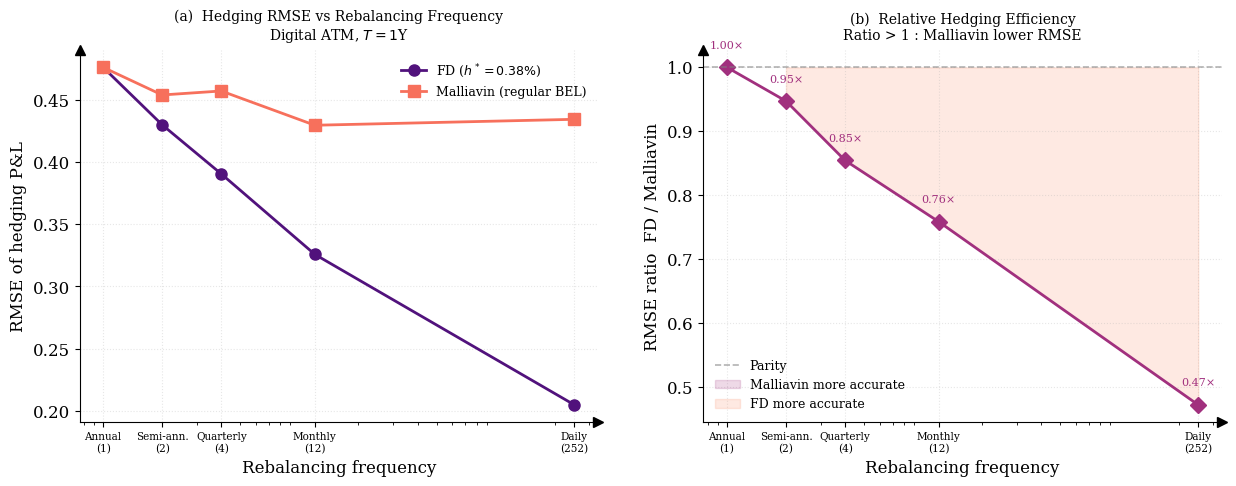

Figure IV.4.2 saved ✓


In [14]:
M_arr   = np.array(M_list)
x_labels = ['Annual\n(1)', 'Semi-ann.\n(2)', 'Quarterly\n(4)',
             'Monthly\n(12)', 'Daily\n(252)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.semilogx(M_arr, rmse_fd_f,  'o-', color=cmap(0.25), lw=2., ms=8,
             label='FD ($h^*=0.38\%$)')
ax1.semilogx(M_arr, rmse_mal_f, 's-', color=cmap(0.70), lw=2., ms=8,
             label='Malliavin (regular BEL)')
ax1.set_xticks(M_arr);  ax1.set_xticklabels(x_labels, fontsize=7.5)
ax1.set_xlabel('Rebalancing frequency', color=C_TEXT)
ax1.set_ylabel('RMSE of hedging P&L', color=C_TEXT)
ax1.set_title('(a)  Hedging RMSE vs Rebalancing Frequency\nDigital ATM, $T=1$Y',
              fontsize=10, pad=8)
ax1.legend(frameon=False, fontsize=9)
add_arrows(ax1)

ratio = rmse_fd_f / np.maximum(rmse_mal_f, 1e-14)
ax2.semilogx(M_arr, ratio, 'D-', color=cmap(0.45), lw=2., ms=8)
ax2.axhline(1., color='gray', lw=1.2, ls='--', alpha=0.6, label='Parity')
ax2.fill_between(M_arr, 1., ratio, where=(ratio>1),
                 alpha=0.18, color=cmap(0.45), label='Malliavin more accurate')
ax2.fill_between(M_arr, ratio, 1., where=(ratio<1),
                 alpha=0.18, color=cmap(0.75), label='FD more accurate')
for m_v, r_v in zip(M_arr, ratio):
    ax2.annotate(f'{r_v:.2f}×', xy=(m_v, r_v), xytext=(m_v, r_v+0.03),
                 ha='center', fontsize=8, color=cmap(0.45))
ax2.set_xticks(M_arr);  ax2.set_xticklabels(x_labels, fontsize=7.5)
ax2.set_xlabel('Rebalancing frequency', color=C_TEXT)
ax2.set_ylabel('RMSE ratio  FD / Malliavin', color=C_TEXT)
ax2.set_title('(b)  Relative Hedging Efficiency\nRatio > 1 : Malliavin lower RMSE',
              fontsize=10, pad=8)
ax2.legend(frameon=False, fontsize=9)
add_arrows(ax2)

plt.tight_layout(pad=2.5)
plt.savefig('figure_hedging_frequency.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_hedging_frequency.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.4.2 saved ✓')

---
## 10. Figure IV.4.3 — Cumulative Portfolio Paths and Terminal P&L

In [15]:
N_viz = 150;  M_viz = 12;  N_inner_viz = 2_000

pnl_vfd,  port_fd  = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
    N_viz, N_steps_outer, M_viz, N_inner_viz,
    payoff='digital', method='fd',       V0=V0_dig, seed_outer=5, return_paths=True)
pnl_vmal, port_mal = run_hedging(S0, v0, K_hdg, T_hdg, r, q, kappa, theta, xi, rho,
    N_viz, N_steps_outer, M_viz, N_inner_viz,
    payoff='digital', method='malliavin', V0=V0_dig, seed_outer=5, return_paths=True)

t_grid = np.linspace(0, T_hdg, M_viz+1)
print(f'Cumulative paths ✓  FD RMSE={np.sqrt(np.mean(pnl_vfd**2)):.5f}  '
      f'Mal RMSE={np.sqrt(np.mean(pnl_vmal**2)):.5f}')

Cumulative paths ✓  FD RMSE=0.36740  Mal RMSE=0.44803


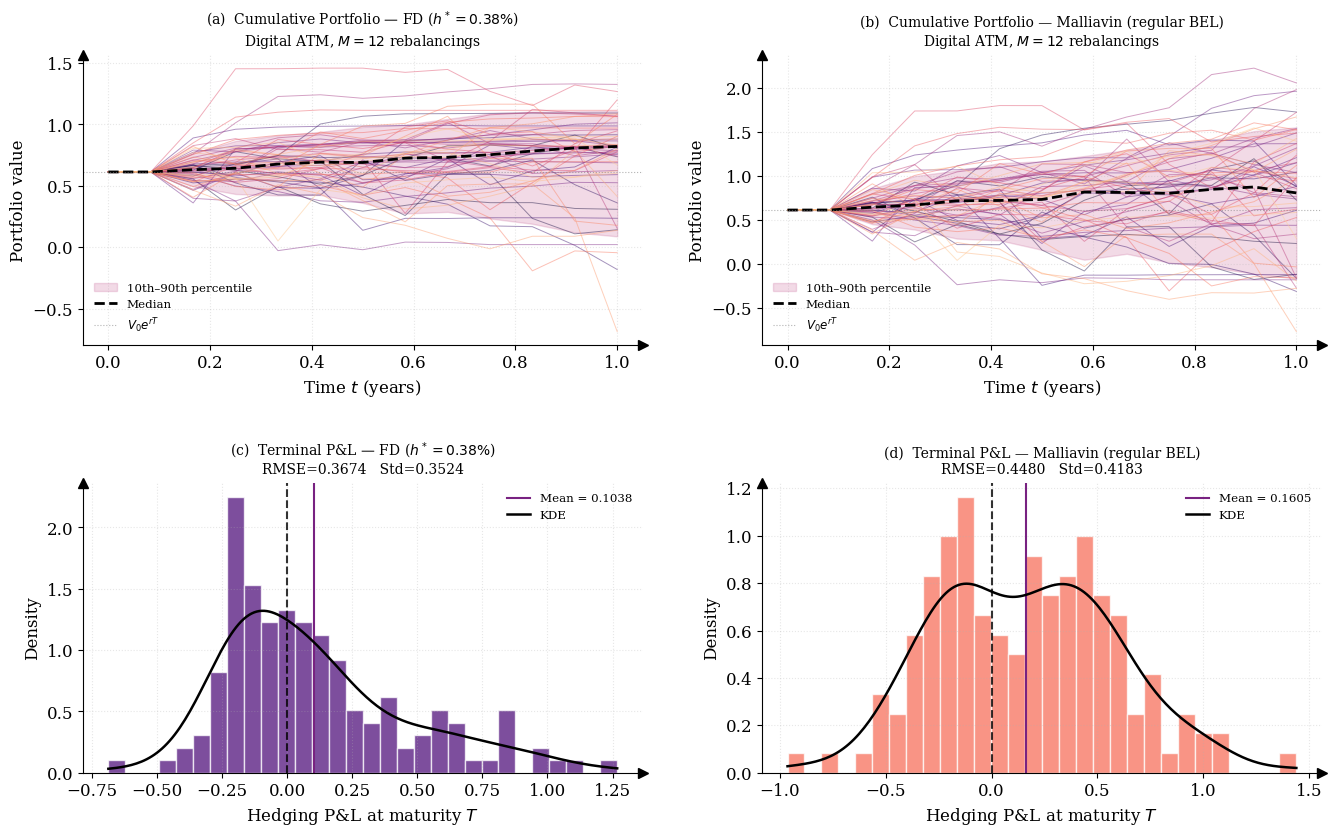

Figure IV.4.3 saved ✓


In [16]:
N_show  = 60
col_map = [cmap(0.10 + 0.80*i/(N_show-1)) for i in range(N_show)]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, (port, pnl_v, label, c_hist) in enumerate([
    (port_fd,  pnl_vfd,  'FD ($h^*=0.38\%$)',       cmap(0.25)),
    (port_mal, pnl_vmal, 'Malliavin (regular BEL)',  cmap(0.70)),
]):
    # ─── Cumulative portfolio paths ───────────────────────────────────
    ax = axes[0, col]
    for i in range(N_show):
        ax.plot(t_grid, port[:, i], color=col_map[i], lw=0.7, alpha=0.45)
    q10 = np.percentile(port, 10, axis=1)
    q50 = np.percentile(port, 50, axis=1)
    q90 = np.percentile(port, 90, axis=1)
    ax.fill_between(t_grid, q10, q90, alpha=0.18, color=cmap(0.50),
                    label='10th–90th percentile')
    ax.plot(t_grid, q50, color='black', lw=2., ls='--', label='Median')
    ax.axhline(V0_dig*np.exp(r*T_hdg), color='gray', lw=0.8,
               ls=':', alpha=0.6, label='$V_0 e^{rT}$')
    add_arrows(ax)
    ax.set_xlabel('Time $t$ (years)', color=C_TEXT)
    ax.set_ylabel('Portfolio value', color=C_TEXT)
    ax.set_title(f'({chr(97+col)})  Cumulative Portfolio — {label}\n'
                 f'Digital ATM, $M={M_viz}$ rebalancings',
                 fontsize=10, pad=7)
    ax.legend(frameon=False, fontsize=8.5)

    # ─── Terminal P&L histogram + KDE ────────────────────────────────
    ax2 = axes[1, col]
    ax2.hist(pnl_v, bins=30, density=True,
             color=c_hist, alpha=0.75, edgecolor='white', lw=0.5)
    ax2.axvline(0., color='black', lw=1.5, ls='--', alpha=0.8)
    ax2.axvline(np.mean(pnl_v), color=cmap(0.35), lw=1.5,
                label=f'Mean = {np.mean(pnl_v):.4f}')
    kde = gaussian_kde(pnl_v, bw_method='silverman')
    x_k = np.linspace(pnl_v.min(), pnl_v.max(), 200)
    ax2.plot(x_k, kde(x_k), color='black', lw=1.8, label='KDE')
    add_arrows(ax2)
    ax2.set_xlabel('Hedging P&L at maturity $T$', color=C_TEXT)
    ax2.set_ylabel('Density', color=C_TEXT)
    rmse_v = np.sqrt(np.mean(pnl_v**2));  std_v = np.std(pnl_v)
    ax2.set_title(f'({chr(99+col)})  Terminal P&L — {label}\n'
                  f'RMSE={rmse_v:.4f}   Std={std_v:.4f}',
                  fontsize=10, pad=7)
    ax2.legend(frameon=False, fontsize=8.5)

plt.tight_layout(pad=2.5)
plt.savefig('figure_hedging_paths.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_hedging_paths.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.4.3 saved ✓')

---
## 11. Summary Table — LaTeX Export

*(Table IV.4 of the thesis)*

In [17]:
print('═'*80)
print(f'Table IV.4  —  Hedging Performance Summary')
print(f'(M={M_rebal} rebalancings, N={N_outer} outer paths, N_inner={N_inner})')
print('═'*80)
header = f'{"Strategy":>24}  {"Mean":>8}  {"Std":>8}  {"RMSE":>8}  {"P5":>8}  {"P95":>8}'
print(header);  print('─'*80)
entries = [
    ('Call — No hedge',      pnl_nh_call),
    ('Call — FD',            pnl_call_fd),
    ('Call — Malliavin',     pnl_call_mal),
    ('Digital — No hedge',   pnl_nh_dig),
    ('Digital — FD',         pnl_dig_fd),
    ('Digital — Malliavin',  pnl_dig_mal),
]
for name, pnl_v in entries:
    print(f'{name:>24}  '
          f'{np.mean(pnl_v):8.5f}  {np.std(pnl_v):8.5f}  '
          f'{np.sqrt(np.mean(pnl_v**2)):8.5f}  '
          f'{np.percentile(pnl_v, 5):8.5f}  {np.percentile(pnl_v, 95):8.5f}')
print('═'*80)

latex_rows = [
    r'\begin{table}[h!]\centering',
    r'\begin{tabular}{llccccc}\toprule',
    r'Payoff & Method & Mean & Std & RMSE & $P_5$ & $P_{95}$ \\\midrule',
]
for payoff_l, method_l, pnl_v in [
    ('Call',    'No hedge',           pnl_nh_call),
    ('Call',    'FD ($h^*=0.38\%$)',  pnl_call_fd),
    ('Call',    'Malliavin reg.',      pnl_call_mal),
    ('Digital', 'No hedge',           pnl_nh_dig),
    ('Digital', 'FD ($h^*=0.38\%$)',  pnl_dig_fd),
    ('Digital', 'Malliavin reg.',      pnl_dig_mal),
]:
    latex_rows.append(
        f'{payoff_l} & {method_l} & '
        f'${np.mean(pnl_v):.4f}$ & ${np.std(pnl_v):.4f}$ & '
        f'${np.sqrt(np.mean(pnl_v**2)):.4f}$ & '
        f'${np.percentile(pnl_v,5):.4f}$ & '
        f'${np.percentile(pnl_v,95):.4f}$ \\\\')
latex_rows += [
    r'\bottomrule\end{tabular}',
    r'\caption{\textbf{Dynamic Delta-hedging performance.}'
    r' $M=12$ monthly rebalancings, $T=1$Y, ATM ($K=S_0$),'
    r' $N=' + str(N_outer) + r'$ outer paths, $N_{inner}=' + str(N_inner) + r'$.}',
    r'\label{tab:hedging_performance}\end{table}',
]
with open('table_hedging_performance.tex', 'w') as f:
    f.write('\n'.join(latex_rows))
print('LaTeX table saved: table_hedging_performance.tex ✓')

════════════════════════════════════════════════════════════════════════════════
Table IV.4  —  Hedging Performance Summary
(M=12 rebalancings, N=400 outer paths, N_inner=2000)
════════════════════════════════════════════════════════════════════════════════
                Strategy      Mean       Std      RMSE        P5       P95
────────────────────────────────────────────────────────────────────────────────
         Call — No hedge  -20.26934  630.87353  631.19906  -1201.60038  538.11275
               Call — FD  121.31846  302.34834  325.78013  -438.13556  547.81450
        Call — Malliavin  170.05676  507.17299  534.92406  -698.09248  1001.33952
      Digital — No hedge  -0.04192   0.47537   0.47721  -0.38692   0.61308
            Digital — FD   0.03027   0.29776   0.29929  -0.34838   0.61779
     Digital — Malliavin   0.11419   0.45965   0.47362  -0.61144   0.96253
════════════════════════════════════════════════════════════════════════════════
LaTeX table saved: table_hedging_pe

---
## 12. JSON Update

In [18]:
cal.update({
    'hedging_M_rebal':          M_rebal,
    'hedging_N_outer':          N_outer,
    'hedging_N_inner':          N_inner,
    'rmse_call_fd_monthly':     float(np.sqrt(np.mean(pnl_call_fd**2))),
    'rmse_call_mal_monthly':    float(np.sqrt(np.mean(pnl_call_mal**2))),
    'rmse_digital_fd_monthly':  float(np.sqrt(np.mean(pnl_dig_fd**2))),
    'rmse_digital_mal_monthly': float(np.sqrt(np.mean(pnl_dig_mal**2))),
    'hedging_M_list':           M_list,
    'rmse_fd_by_freq':          rmse_fd_f.tolist(),
    'rmse_mal_by_freq':         rmse_mal_f.tolist(),
})
with open('heston_calibrated_params.json', 'w') as f:
    json.dump(cal, f, indent=2)

print('JSON updated → heston_calibrated_params.json ✓')
print()
print('Files generated in this notebook:')
print('  📊 figure_pnl_distributions.pdf  — P&L distributions call & digital (Fig IV.4.1)')
print('  📊 figure_hedging_frequency.pdf  — RMSE vs rebalancing frequency   (Fig IV.4.2)')
print('  📊 figure_hedging_paths.pdf      — Cumulative paths + terminal P&L  (Fig IV.4.3)')
print('  📄 table_hedging_performance.tex — Hedging summary table            (Table IV.4)')
print('  💾 heston_calibrated_params.json — Updated')

JSON updated → heston_calibrated_params.json ✓

Files generated in this notebook:
  📊 figure_pnl_distributions.pdf  — P&L distributions call & digital (Fig IV.4.1)
  📊 figure_hedging_frequency.pdf  — RMSE vs rebalancing frequency   (Fig IV.4.2)
  📊 figure_hedging_paths.pdf      — Cumulative paths + terminal P&L  (Fig IV.4.3)
  📄 table_hedging_performance.tex — Hedging summary table            (Table IV.4)
  💾 heston_calibrated_params.json — Updated
